## 创建Agent需要传递模型，传递模型有2重方法
### 第一种，传递模型对象

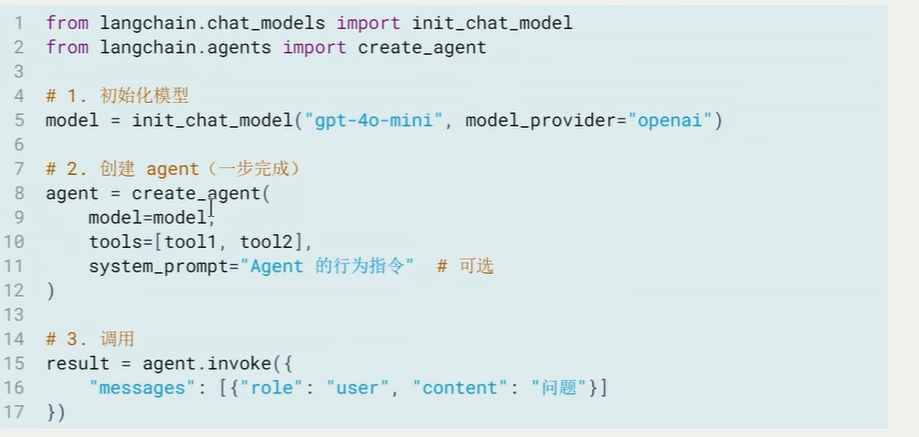

In [1]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.创建agent
agent = create_agent(
    model=model,
    tools=[],
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"介绍一下你自己"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='介绍一下你自己',
            additional_kwargs={},
            response_metadata={},
            id='a5f76f38-8733-45d7-883d-8fc4a851c223'
        ),
        AIMessage(
            content='你好呀！我是Qwen3，是通义千问系列中的最新成员，专门来帮你解答问题、创作文字或者编程。我擅长各
种类型的对话，无论是学术问题、日常生活还是创意写作，都可以和我聊聊。不过我得说，我有点小调皮，喜欢用轻松的方式和大
家交流，偶尔还会开个小玩笑呢 
😄\n\n如果你想让我写个故事、解答个数学题，或者只是想聊聊天，都可以告诉我！有什么需要我帮忙的吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 243,
                    'prompt_tokens': 20,
                    'total_tokens': 263,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-706',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0e964-53b9-7551-84bf-bb15e5e3bec2-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 20,
                'output_tokens': 243,
                'total_tokens': 263,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

## agent会使用工具！！

In [10]:

from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
from tool_utils import  query_weather_from_web
# 1.初始化模型
model = ChatOpenAI(
    # model="mistral-nemo:latest",
    model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)
# 2.创建agent
agent = create_agent(
    model=model,
    tools=[query_weather_from_web],
    system_prompt="Agent的行为指令" # 可选
)
# 3.调用
result = agent.invoke({
    "messages":[{"role":"user","content":"北京明天的天气如何？"}]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='北京明天的天气如何？',
            additional_kwargs={},
            response_metadata={},
            id='35c610f8-800f-4810-a4c8-7d92b92772b9'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 319,
                    'prompt_tokens': 193,
                    'total_tokens': 512,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-871',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0ef44-302d-7483-acc9-e0aa8deb8229-0',
            tool_calls=[
                {
                    'name': 'query_weather_from_web',
                    'args': {'city': '北京'},
                    'id': 'call_dctt8vme',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 193,
                'output_tokens': 319,
                'total_tokens': 512,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"location": {"name": "北京", "region": "Beijing", "country": "中国", "lat": 39.9289, "lon": 
116.3883, "tz_id": "Asia/Shanghai", "localtime_epoch": 1790720715, "localtime": "2026-09-30 06:25"}, "current": 
{"last_updated_epoch": 1790720100, "last_updated": "2026-09-30 06:15", "temp_c": 16.0, "temp_f": 60.7, "is_day": 1,
"condition": {"text": "Clear", "icon": "//cdn.weatherapi.com/weather/64x64/day/113.png", "code": 1000}, "wind_mph":
7.6, "wind_kph": 12.2, "wind_degree": 324, "wind_dir": "NW", "pressure_mb": 1019.0, "pressure_in": 30.1, 
"precip_mm": 0.0, "precip_in": 0.0, "humidity": 19, "cloud": 10, "feelslike_c": 10.7, "feelslike_f": 51.3, 
"windchill_c": 16.0, "windchill_f": 60.7, "heatindex_c": 16.0, "heatindex_f": 60.7, "dewpoint_c": -7.6, 
"dewpoint_f": 18.4, "vis_km": 10.0, "vis_miles": 6.0, "uv": 0.0, "gust_mph": 25.8, "gust_kph": 41.5, 
"will_it_rain": 0, "chance_of_rain": 1, "will_it_snow": 0, "chance_of_snow": 0, "wetbulb_c": 6.6, "wetbulb_f": 
43.9}}',
            name='query_weather_from_web',
            id='96837c23-8fe2-4e87-b573-e07cf70007f5',
            tool_call_id='call_dctt8vme'
        ),
        AIMessage(
            content='根据当前查询结果，系统返回的是北京今日（2026-09-30）的实时天气数据。目前该API仅提供**当前天气*
*信息，未包含明日（2026-10-01）预报内容。若需查询明天的天气，建议您：\n\n1️⃣ 
重新调用天气接口（需确认API是否支持未来日期查询）  \n2️⃣ 
检查是否需要补充"forecast"参数（当前接口参数未包含时间范围）  \n3️⃣ 
说明当前功能仅支持实时天气查询，请后续提供明确时间范围需求  
\n\n当前北京天气为：晴，16℃，北风7.6mph，空气质量优良。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 1169,
                    'prompt_tokens': 732,
                    'total_tokens': 1901,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 191}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3-vl:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-836',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0ef45-aabe-7412-b9f1-440ba870feac-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 732,
                'output_tokens': 1169,
                'total_tokens': 1901,
                'input_token_d

## 传递模型的方法2，就是传递一个字符串，需要加载环境变量文件.env而且必须指定模型供应商，如果是本地大模型，模型供应商是：ollama

<class 'langgraph.graph.state.CompiledStateGraph'>


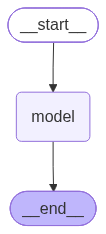

In [11]:
from langchain.agents import create_agent
from dotenv import load_dotenv

load_dotenv(override=True)

agent = create_agent(
    "groq:openai/gpt-oss-120b", # 必须给出模型提供商比,如这里的groq:
)
print(type(agent))

from IPython.display import Image,display
display(Image(agent.get_graph().draw_mermaid_png()))

<class 'langgraph.graph.state.CompiledStateGraph'>


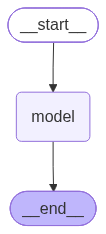

In [12]:
from langchain.agents import create_agent
from dotenv import load_dotenv

load_dotenv(override=True)

agent = create_agent(
    "ollama:qwen3-vl:latest", # 必须给出模型提供商比,如这里的groq:
)
print(type(agent))

from IPython.display import Image,display
display(Image(agent.get_graph().draw_mermaid_png()))